In [1]:
import mdtraj as md
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from rb_potential import ryckaert_bellemans

# Ryckaert–Bellemans potential demo
Cell below demonstrates usage of ``ryckaert_bellemans`` function to compute the energy of a diheral angle.
The parameters used are from the GROMACS documentation.
The chart looks the same as in GROMACS documentation [Gromacs Docs RB link](https://manual.gromacs.org/current/reference-manual/functions/bonded-interactions.html#proper-dihedrals-ryckaert-bellemans-function)

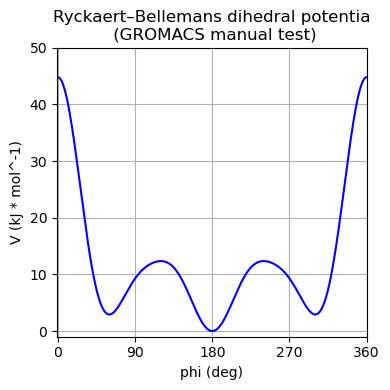

In [68]:
# Demo: compute and plot RB potential with GROMACS documentation parameters
C = (9.28, 12.16, -13.12, -3.06, 26.24, -31.5)
phis = np.linspace(0, 360, 721)
energies = ryckaert_bellemans(phis, C)

plt.figure(figsize=(4,4))
plt.plot(phis, energies, '-b')
plt.xlim((-1, 360))
plt.xticks(np.arange(0,361, 90))
plt.ylim((-1, 50))
plt.xlabel('phi (deg)')
plt.ylabel('V (kJ * mol^-1)')
plt.title('Ryckaert–Bellemans dihedral potentia\n (GROMACS manual test)')
plt.grid(True)
plt.tight_layout()
plt.show()

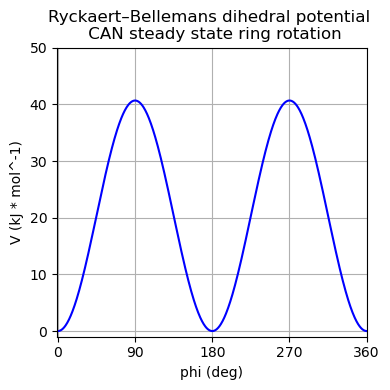

In [91]:
# RB potential of the ring rotation torsion from the CAN forcefield
C = [40.68522, 0.0, -40.68522, 0, 0, 0]
phis = np.linspace(0, 360, 721)
energies = ryckaert_bellemans(phis, C)

plt.figure(figsize=(4,4))
plt.plot(phis, energies, '-b')
plt.xlim((-1, 360))
plt.xticks(np.arange(0,361, 90))
plt.ylim((-1, 50))
plt.xlabel('phi (deg)')
plt.ylabel('V (kJ * mol^-1)')
plt.title('Ryckaert–Bellemans dihedral potential \n CAN steady state ring rotation')
plt.grid(True)
plt.tight_layout()
plt.show()

# Optimization of parameters for Excited state CAN
Rotational torsion atom IDs are `[15, 7, 19, 23]` and `[16, 8, 20, 24]` with steady state parameters `C = [40.68522, 0.0, -40.68522, 0, 0, 0]`

The only rotational dihedral to change is the one of the ring that lies in the C-terminal domain of the OCP. In our assembled system, that is the ring with `O02` oxygen atom. The corresponding torsion atom IDs are `[16, 8, 20, 24]`.

In the scan structures, the corresponding torsion atom IDs are `[18, 23, 24, 26]`

**Important note: mdtraj indices are from zero, and my indices are from PDB and forcefield (start from 1)**

The plan is:
- Load the Energy data;
- Extract torsion values from the structures;
- Compute new parameters.


## Data Loading 

In [30]:
df = pd.read_csv('S1a.txt',
                delimiter=r'\s+',
                names=['angle', 'energy', 'energy_au', 'energy_kcal_mol'],
                decimal=',',
                skiprows=1
                )
df['energy_kj_mol'] = df['energy_kcal_mol'] * 4.184
df.head()

,angle,energy,energy_au,energy_kcal_mol,energy_kj_mol
0,0,-1620.8235213,0.00555,3.478,14.551952
1,10,-1620.8249083,0.00655,4.107,17.183688
2,20,-1620.8241577,0.00731,4.578,19.154352
3,30,-1620.8247376,0.00672,4.214,17.631376
4,40,-1620.8257201,0.00574,3.598,15.054032


## Extracting Torsion Angles


#### Quickfix
scan_structures appear to be in strange EUC-JP encoding which cannot be read by mdtraj. quick convertation below

In [6]:
os.makedirs('scan_structures_utf8', exist_ok=True)
for file in os.listdir('scan_structures'):
    os.system(f"iconv -f EUC-JP -t UTF-8 scan_structures/{file} > scan_structures_utf8/{file}")

In [32]:
torsion_indices = [17, 22, 23, 25]
torsion_real_angle = []

for file in os.listdir('scan_structures_utf8'):
    p = f'./scan_structures_utf8/{str(file)}'
    structure = md.load(p)
    torsion_real_angle.append((int(file.split('.')[0]), md.compute_dihedrals(structure, [torsion_indices])[0][0]*180/np.pi))

In [45]:
df_torsions = df.merge(pd.DataFrame(torsion_real_angle, columns=['angle', 'angle_real']))
df_torsions['angle_real'] = (df_torsions['angle_real']+ 180) % 360
df_torsions.head(5)

,angle,energy,energy_au,energy_kcal_mol,energy_kj_mol,angle_real
0,0,-1620.8235213,0.00555,3.478,14.551952,6.834091
1,10,-1620.8249083,0.00655,4.107,17.183688,355.806793
2,20,-1620.8241577,0.00731,4.578,19.154352,346.219849
3,30,-1620.8247376,0.00672,4.214,17.631376,335.382996
4,40,-1620.8257201,0.00574,3.598,15.054032,325.775452


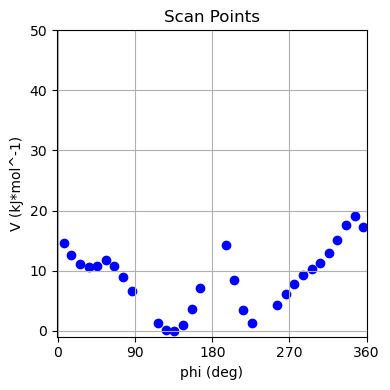

In [57]:
plt.figure(figsize=(4,4))
plt.scatter(df_torsions.angle_real, df_torsions.energy_kj_mol, color='b')
plt.xlim((-1, 360))
plt.xticks(np.arange(0,361, 90))
plt.ylim((-1, 50))
plt.xlabel('phi (deg)')
plt.ylabel('V (kJ*mol^-1)')
plt.title('Scan Points')
plt.grid(True)
plt.tight_layout()
plt.show()

## Optimization
Using scipy 

In [59]:
from scipy import optimize

In [64]:
def rb_curve_wrapper(phi, *C):
    C = np.array(C)
    return ryckaert_bellemans(phi, C)

In [86]:
def residuals(C, phi, E_qm):
    return ryckaert_bellemans(phi, C) - E_qm

res = optimize.least_squares(residuals, x0=np.zeros(6), args=(df_torsions.angle_real, df_torsions.energy_kj_mol))

In [87]:
C = res.x

In [88]:
C

array([  6.99608621, -11.33165279, -10.30992392,   3.49594568,
        17.63220952,   5.91839731])

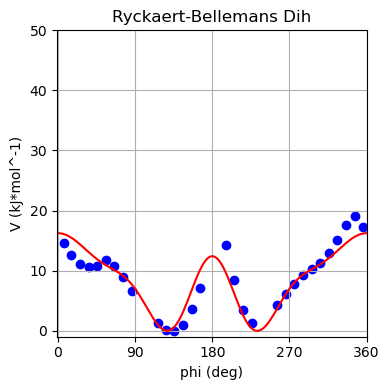

In [89]:
C = res.x
phis = np.linspace(0, 360, 721)
energies = ryckaert_bellemans(phis, C)

plt.figure(figsize=(4,4))
plt.scatter(df_torsions.angle_real, df_torsions.energy_kj_mol, color='b')
plt.plot(phis, energies, '-r',)
plt.xlim((-1, 360))
plt.xticks(np.arange(0,361, 90))
plt.ylim((-1, 50))
plt.xlabel('phi (deg)')
plt.ylabel('V (kJ*mol^-1)')
plt.title('Ryckaert-Bellemans Dih')
plt.grid(True)
plt.tight_layout()
plt.show()

### Result
`C = [6.99609, -11.33165, -10.30992, 3.49595, 17.63221, 5.91840]`